## SITCOM-1950
Karla Peña Ramírez

We want to determine the most frequent alarms triggered during the ComCam on Sky campaign. Here are presented histogram visualizations for the alarm names, reasons and acknowledgement status. It is also presented time series visualizations showing the number of alarms per day, and by hour and day of the week.

In [1]:
#Setting packages
import asyncio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
import time
import warnings
import seaborn as sns
import datetime as dt
from scipy import stats
from matplotlib.dates import DateFormatter
from astropy.table import Table, join
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import IsolationForest
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from lsst.utils.packages import getEnvironmentPackages
#%matplotlib widget

from astropy.time import Time, TimeDelta
from lsst_efd_client.efd_helper import merge_packed_time_series
from lsst.meas.algorithms.installGaussianPsf import FwhmPerSigma
from lsst.daf.butler import Butler 
#from tqdm.notebook import tqdm

# Ignore the many warning messages from ``merge_packed_time_series``
warnings.simplefilter(action="ignore", category=FutureWarning)

#-------Clients
from lsst_efd_client import EfdClient
client = EfdClient("usdf_efd")

#from lsst.summit.utils.efdUtils import makeEfdClient
#client = makeEfdClient()

#from lsst.summit.utils import ConsDbClient
#os.environ["no_proxy"] += ",.consdb"
#url="http://consdb-pq.consdb:8080/consdb"
#consdb=ConsDbClient(url)
#-------Clients

def print_session_info():
    # Time info
    print(f"# Session Info on {time.strftime('%Y-%m-%d at %H:%M:%S %Z', time.localtime(time.time()))}\n")

    # Python info
    print(f"## Python Interpreter\n\nVersion: {sys.version}  \nExecutable: {sys.executable}\n")

    # LSST info
    packages = getEnvironmentPackages(True)
    dev_packages = {"lsst_distrib": packages["lsst_distrib"]}
    dev_packages.update({k: v.split("@")[0] for k, v in packages.items() if "LOCAL" in v})
    print("## Science Pipelines\n\n" + "\n".join(f"{k:<20} {v}" for k, v in dev_packages.items()))

## Alarms during ComCam campaign

In [2]:
#ComCam campaign window
start = Time("2024-10-17 00:00:00Z", scale="utc")
end = Time("2024-12-12 00:00:00Z", scale="utc")

In [ ]:
#Data retrieval 1. Watcher.
query = f"""
SELECT 
    "name" AS "Name", 
    "reason" AS "Reason", 
    "acknowledged" AS "Acknowledged",
    "severity" AS "Severity",
    "mutedBy" AS "Muted"
FROM "lsst.sal.Watcher.logevent_alarm" 
WHERE time > '{start.isot}Z' 
AND time < '{end.isot}Z'
"""

watcher = await client.influx_client.query(query)

print(f"Total number of alarms: {len(watcher)}")
print(f"Number of unique alarm reasons: {watcher['Reason'].nunique()}")
print("\nAcknowledgment rate: {:.2f}%".format(
    (watcher['Acknowledged'].sum() / len(watcher)) * 100
))

In [ ]:
#Data exploration
#Alarm Distribution by Acknowledgment Status
plt.figure(figsize=(18, 3))
sns.countplot(data=watcher, x='Acknowledged')
plt.title('Distribution of Acknowledged vs Unacknowledged Alarms')
plt.show()


#Alarm Distribution by Severity Status
plt.figure(figsize=(18, 3))
sns.countplot(data=watcher, x='Severity')
plt.title('Distribution of Severity Flag')
plt.show()


From https://github.com/lsst-ts/ts_xml/blob/develop/python/lsst/ts/xml/enums/Watcher.py we know that the severity e is defined as:

NONE = 1\
WARNING = 2\
SERIOUS = 3\
CRITICAL = 4

So let's discard the alarms with severity=NONE and those muted by some user.

In [ ]:
# Filter for severity 2,3,4 only and muted severity 'None'
watcher_filtered = watcher[
    (watcher['Severity'].isin([2, 3, 4])) & 
    (watcher['Muted'] == '')]

print(f"Total number of alarms: {len(watcher_filtered)}")
print(f"Number of unique alarm reasons: {watcher_filtered['Reason'].nunique()}")
print("\nAcknowledgment rate: {:.2f}%".format(
    (watcher['Acknowledged'].sum() / len(watcher_filtered)) * 100
))

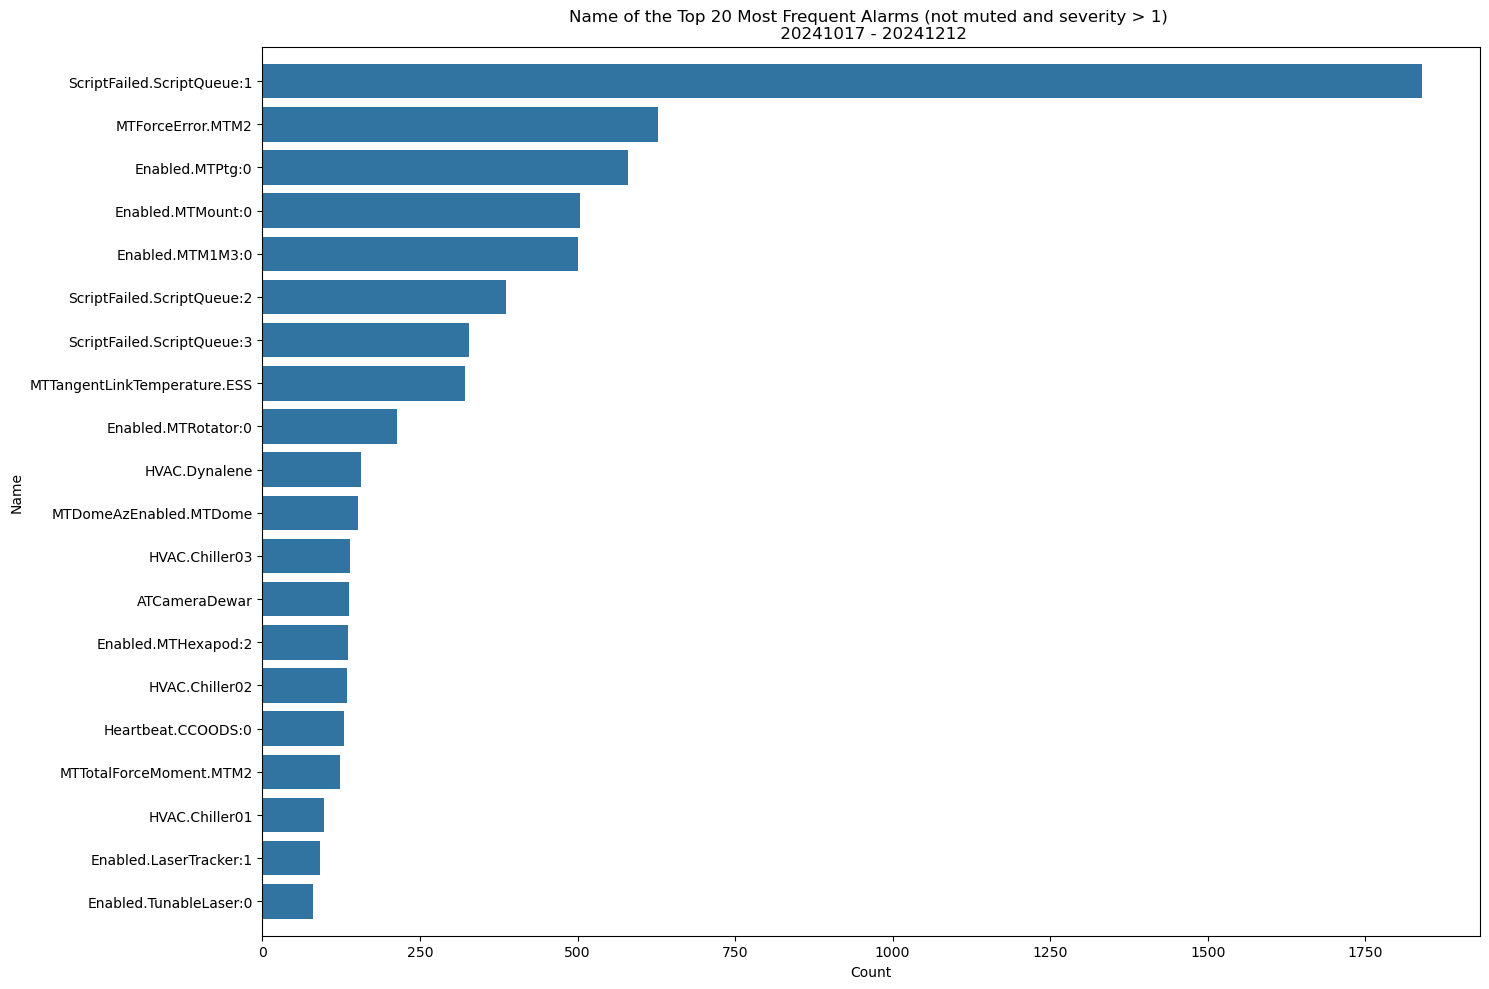

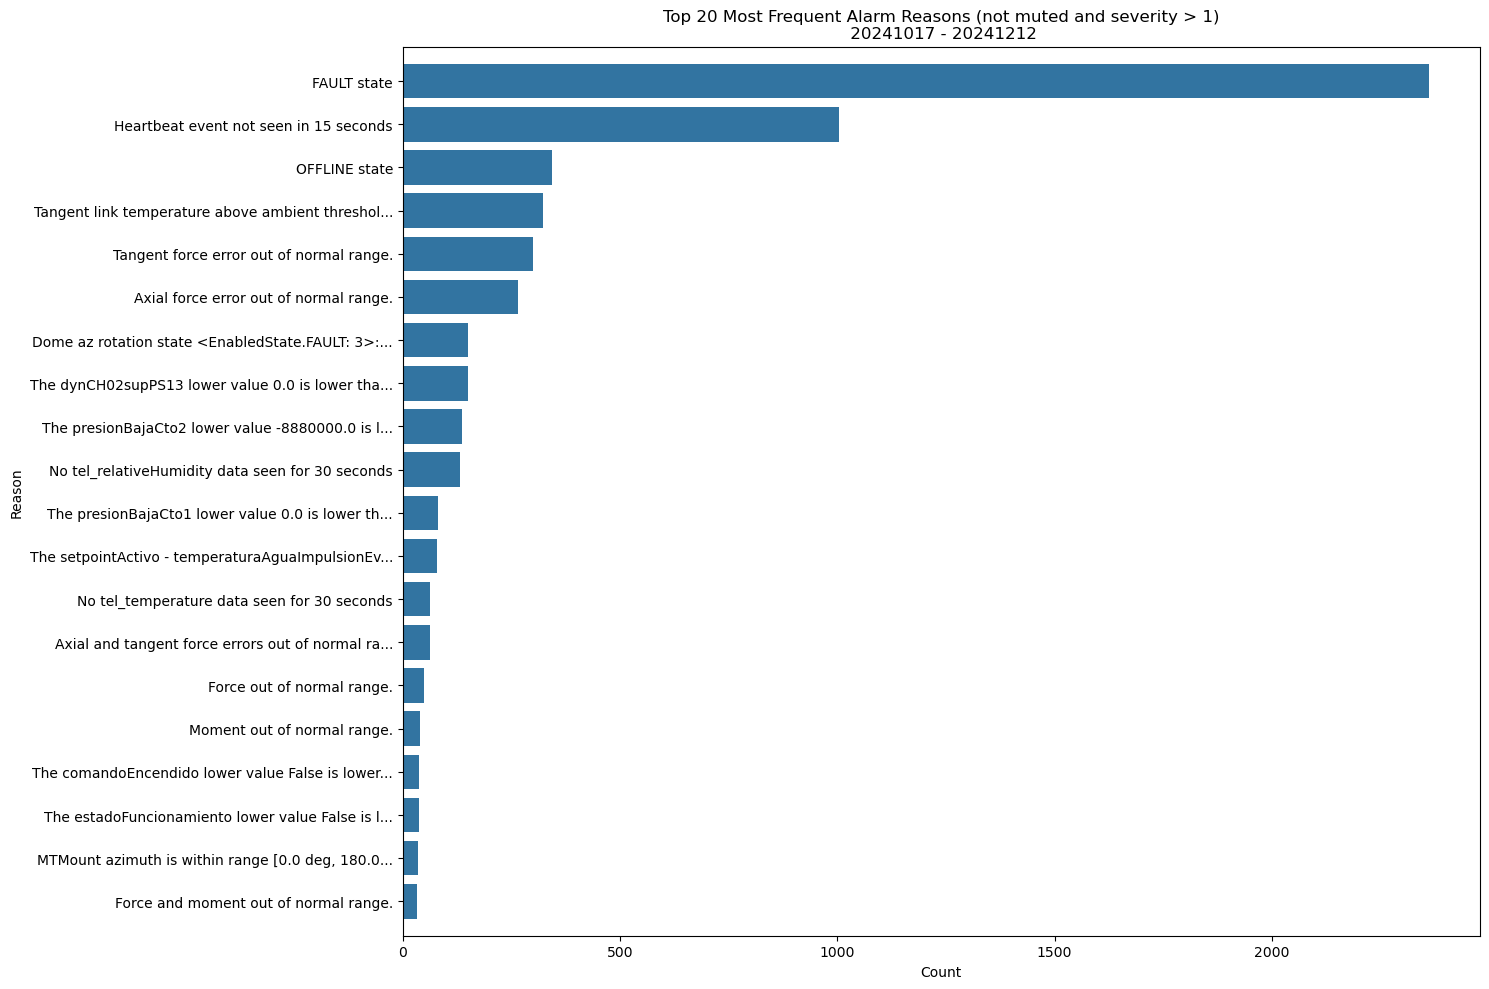

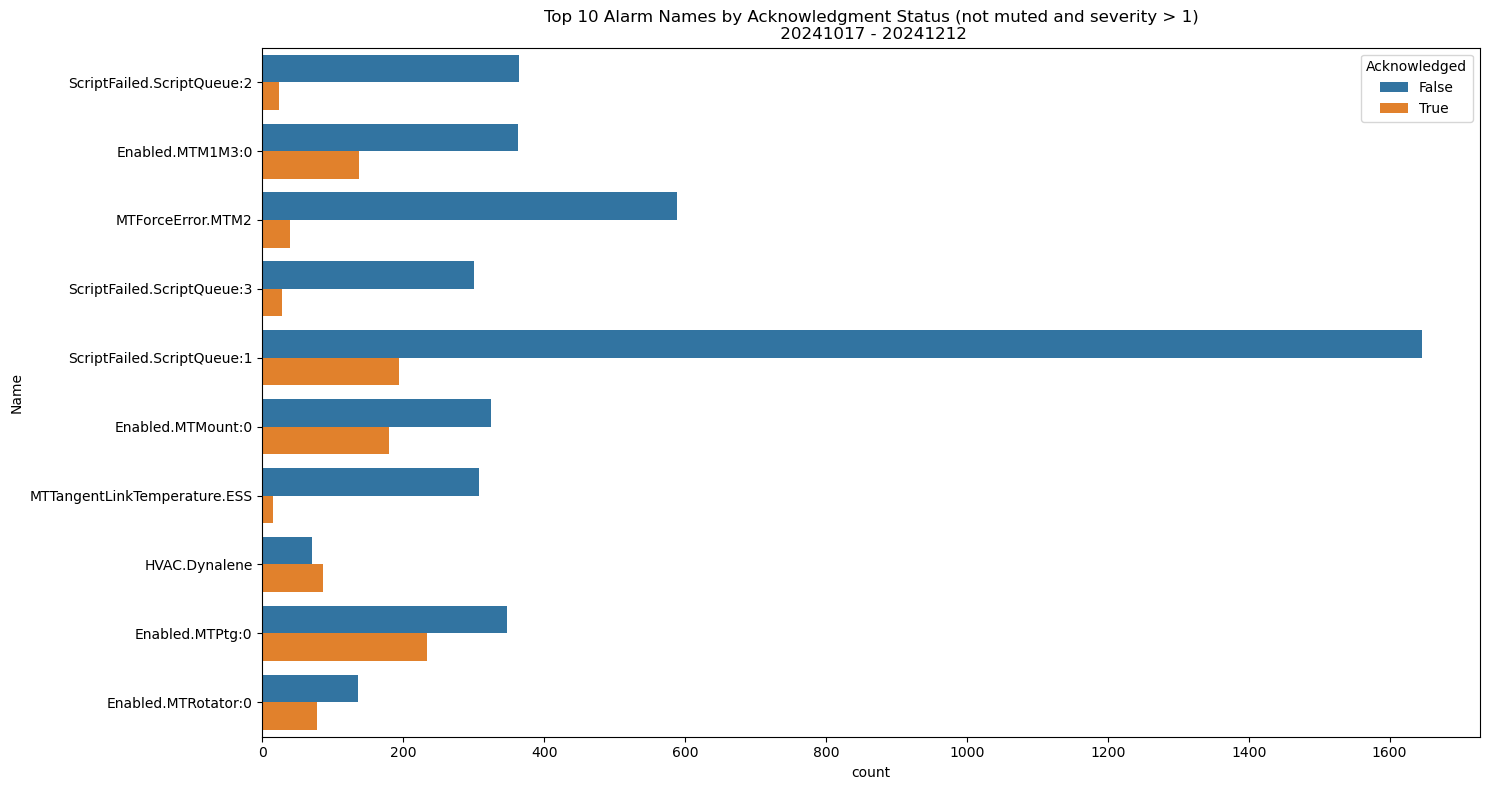

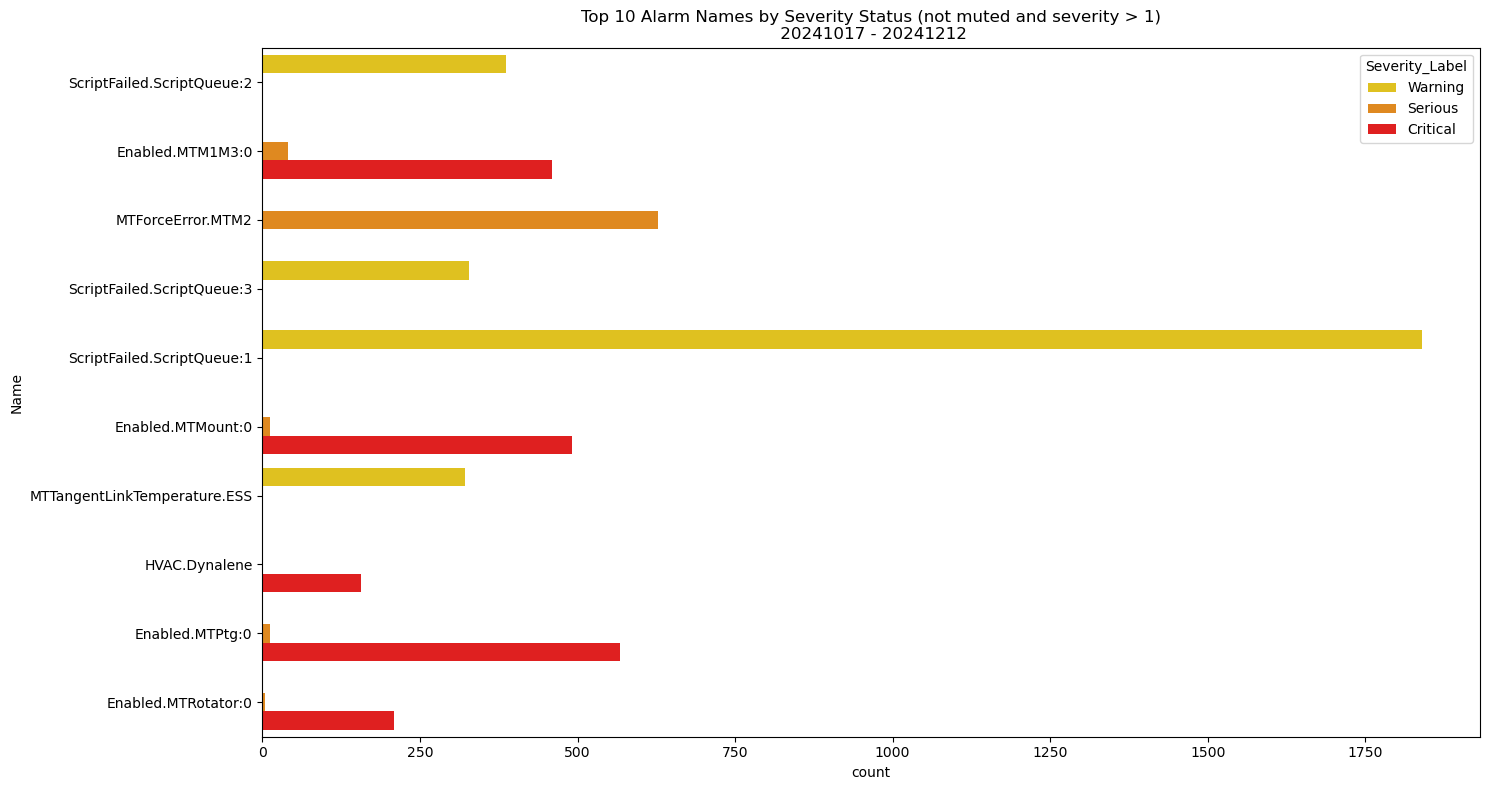

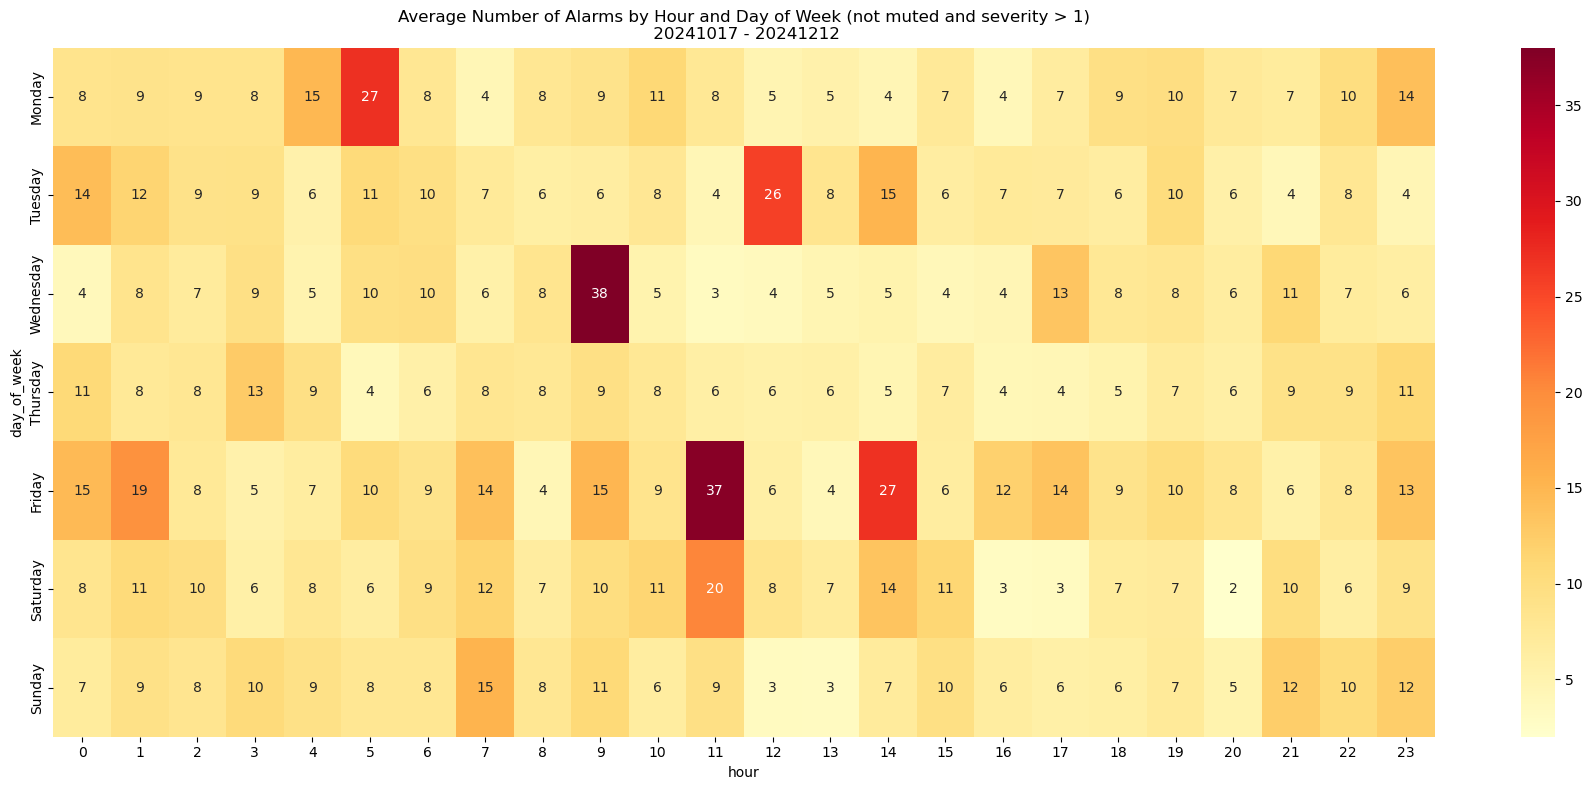

In [18]:
#Visualizations
#Truncate long strings
def truncate_string(s, max_length=50):
    return s if len(s) <= max_length else s[:max_length-3] + '...'

#Name of the Top 20 Most Frequent Alarms (Not muted)
plt.figure(figsize=(15, 10))
name_counts = watcher_filtered['Name'].apply(truncate_string).value_counts().head(20)
sns.barplot(x=name_counts.values, y=name_counts.index)
plt.title('Name of the Top 20 Most Frequent Alarms (not muted and severity > 1) \n 20241017 - 20241212')

plt.xlabel('Count')
plt.ylabel('Name')
plt.tight_layout()
plt.margins(y=0.02)
plt.show()

#Top 20 Most Frequent Reasons for Alarms (Not muted)
plt.figure(figsize=(15, 10))
reason_counts = watcher_filtered['Reason'].apply(truncate_string).value_counts().head(20)
sns.barplot(x=reason_counts.values, y=reason_counts.index)
plt.title('Top 20 Most Frequent Alarm Reasons (not muted and severity > 1)\n 20241017 - 20241212')
plt.xlabel('Count')
plt.ylabel('Reason')
plt.tight_layout()
plt.margins(y=0.02)
plt.show()

#Top 10 Alarm Names with Acknowledgment Status
top_10_names = watcher_filtered['Name'].apply(truncate_string).value_counts().head(10).index
plt.figure(figsize=(15, 8))
name_ack = watcher_filtered[watcher_filtered['Name'].isin(top_10_names)]
sns.countplot(data=name_ack, y='Name', hue='Acknowledged')
plt.title('Top 10 Alarm Names by Acknowledgment Status (not muted and severity > 1)\n 20241017 - 20241212')
plt.tight_layout()
plt.show()


#Top 10 Alarm Names with Severity Status
severity_map = {2: 'Warning', 3: 'Serious', 4: 'Critical'}
watcher_filtered['Severity_Label'] = watcher_filtered['Severity'].map(severity_map)
top_10_names = watcher_filtered['Name'].apply(truncate_string).value_counts().head(10).index
plt.figure(figsize=(15, 8))
custom_palette = ['#FFD700', '#FF8C00', '#FF0000']
name_sev = watcher_filtered[watcher_filtered['Name'].isin(top_10_names)]
sns.countplot(data=name_sev, y='Name', hue='Severity_Label', 
              hue_order=['Warning', 'Serious', 'Critical'], palette=custom_palette)
plt.title('Top 10 Alarm Names by Severity Status (not muted and severity > 1)\n 20241017 - 20241212')
plt.tight_layout()
plt.show()


#####Time Series Analysis
watcher_filtered = watcher[
    (watcher['Severity'].isin([2, 3, 4])) & 
    (watcher['Muted'] == '')
].copy()
#Alarms by Hour and Day of Week
watcher_filtered['hour'] = pd.to_datetime(watcher_filtered.index).hour
watcher_filtered['day_of_week'] = pd.to_datetime(watcher_filtered.index).day_name()
watcher_filtered['date'] = pd.to_datetime(watcher_filtered.index).date
#Moving from counts to means per day per hour
daily_counts = watcher_filtered.groupby(['date', 'day_of_week', 'hour']).size().reset_index(name='count')
alarm_heatmap = daily_counts.groupby(['day_of_week', 'hour'])['count'].mean().unstack()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
alarm_heatmap = alarm_heatmap.reindex(day_order)
plt.figure(figsize=(18, 8))
sns.heatmap(alarm_heatmap, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title('Average Number of Alarms by Hour and Day of Week (not muted and severity > 1)\n 20241017 - 20241212')
plt.tight_layout()
plt.show()

In [ ]:
#Reproducibility
print_session_info()